# MVP — Machine Learning & Analytics

**Nome:** João Victor  
**Matrícula:** _preencher_  
**Data:** _preencher_  
**Dataset:** UCI Heart Disease (Cleveland) 
— https://archive.ics.uci.edu/dataset/45/heart+disease  
**Tipo de problema:** Classificação binária supervisionada

---

## Sobre

Este notebook implementa um MVP para apoiar o diagnóstico de doença cardíaca a partir de atributos clínicos. O fluxo cobre definição do problema, análise exploratória, preparação dos dados, modelagem, otimização de hiperparâmetros, avaliação crítica e conclusão.

# 1. Definição do problema

## 1.1 Descrição do problema

Doenças cardiovasculares são a principal causa de morte no mundo, segundo a Organização Mundial da Saúde. A detecção precoce do estreitamento das artérias coronárias permite intervenções clínicas que reduzem significativamente a mortalidade, mas o diagnóstico definitivo depende de procedimentos invasivos como a angiografia coronariana, que envolvem custo, risco e indisponibilidade em muitos contextos.

Este MVP investiga uma pergunta clínica relevante: até que ponto um conjunto pequeno de atributos obtidos em exames não invasivos (anamnese, eletrocardiograma de repouso, teste ergométrico, perfil lipídico) carrega sinal suficiente para estratificar o risco de doença cardíaca? A resposta apoia o uso de modelos preditivos como ferramenta de triagem, anterior a exames mais sofisticados.

O dataset utilizado é o Cleveland Heart Disease, parte da base UCI Heart Disease, coletado entre 1981 e 1984 no Cleveland Clinic Foundation pelo Dr. Robert Detrano e colaboradores. É o subconjunto mais utilizado na literatura para benchmark de algoritmos preditivos nesse domínio, com 303 registros e 13 atributos clínicos por paciente.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a presença de doença cardíaca em pacientes a partir de 13 atributos clínicos não invasivos, comparando uma linha de base trivial (DummyClassifier) com quatro modelos candidatos (LogisticRegression, RandomForest, GradientBoosting e XGBoost), aplicando otimização de hiperparâmetros e avaliando os resultados com métricas adequadas ao contexto clínico de triagem.

A escolha da melhor solução considera não apenas acurácia, mas também o equilíbrio entre sensibilidade (recall da classe positiva) e especificidade, dado o custo assimétrico de erros diagnósticos.


## 1.3 Tipo de problema

**Classificação binária supervisionada.**

A variável alvo original (`num`) é codificada com cinco níveis (0 a 4), em que 0 indica ausência de doença e 1 a 4 indicam diferentes graus de estreitamento arterial. Seguindo a convenção predominante na literatura sobre este dataset, o target é binarizado:

- **0**: ausência de doença cardíaca (estreitamento inferior a 50% do diâmetro arterial)
- **1**: presença de doença cardíaca (estreitamento igual ou superior a 50%, agregando os níveis 1, 2, 3 e 4)

A binarização é justificada porque os subníveis de severidade têm fronteiras clínicas pouco nítidas no dataset, e o desbalanceamento entre eles (164 vs 55 vs 36 vs 35 vs 13 registros) inviabilizaria a classificação multiclasse confiável em uma base de apenas 303 amostras.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Premissas:**

1. Os atributos clínicos coletados refletem fielmente o estado de cada paciente no momento do exame, sem erros sistemáticos de medição.
2. A população amostrada (clínica cardiológica especializada) tem distribuição de risco superior à população geral, o que limita a generalização do modelo para triagem populacional.
3. A relação entre atributos e desfecho é estável ao longo do tempo, apesar de o dataset ser dos anos 80; mudanças em estilo de vida e perfil populacional não são modeladas aqui.

**Hipóteses iniciais:**

1. Idade, sexo, tipo de dor torácica (`cp`) e frequência cardíaca máxima atingida (`thalach`) devem aparecer entre as variáveis mais informativas, com base em conhecimento clínico prévio.
2. Modelos baseados em árvores devem superar a regressão logística, capturando interações não lineares entre fatores de risco.
3. A acurácia esperada está na faixa de 80% a 85%, com base em estudos anteriores que utilizam o mesmo dataset.

**Critérios de sucesso:**

1. Superar o baseline trivial (classe majoritária) com margem clara em F1 e ROC AUC.
2. Atingir recall da classe positiva de pelo menos 0.80, dado o custo elevado de falsos negativos em contexto clínico.
3. Demonstrar reprodutibilidade total do notebook, com seed fixa e dataset carregado por URL pública.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
from scipy.stats import randint, uniform

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed fixa:", SEED)


Python: 3.13.3
Seed fixa: 42


## 2.1 Dependências

In [2]:
!pip install -q xgboost


## 2.2 Funções auxiliares


In [3]:
def evaluate_binary_classification(y_true, y_pred, proba=None):
    """Calcula métricas para classificação binária, incluindo PR AUC."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if proba is not None:
        try:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
            results["pr_auc"] = average_precision_score(y_true, proba[:, 1])
        except Exception:
            results["roc_auc"] = np.nan
            results["pr_auc"] = np.nan
    return results


def show_results_table(results_dict, sort_by="f1"):
    """Exibe resultados como DataFrame ordenado pela métrica escolhida."""
    df_res = pd.DataFrame(results_dict).T
    if sort_by in df_res.columns:
        df_res = df_res.sort_values(by=sort_by, ascending=False)
    return df_res.round(4)


def plot_confusion(y_true, y_pred, title="Matriz de confusão", labels=("Sem doença", "Com doença")):
    """Plota matriz de confusão com rótulos clínicos."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_pr(y_true, proba, model_name="Modelo"):
    """Plota curvas ROC e Precision-Recall lado a lado."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    fpr, tpr, _ = roc_curve(y_true, proba)
    auc_roc = roc_auc_score(y_true, proba)
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC={auc_roc:.3f})")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[0].set_xlabel("Taxa de falsos positivos")
    axes[0].set_ylabel("Taxa de verdadeiros positivos")
    axes[0].set_title("Curva ROC")
    axes[0].legend(loc="lower right")

    prec, rec, _ = precision_recall_curve(y_true, proba)
    auc_pr = average_precision_score(y_true, proba)
    axes[1].plot(rec, prec, label=f"{model_name} (AP={auc_pr:.3f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Curva Precision-Recall")
    axes[1].legend(loc="lower left")

    plt.tight_layout()
    plt.show()


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Dataset:** Heart Disease Data Set (subconjunto Cleveland)  
**Origem oficial:** UCI Machine Learning Repository  
**Link:** https://archive.ics.uci.edu/dataset/45/heart+disease  
**Doadores originais:** Andras Janosi (Hungarian Institute of Cardiology), William Steinbrunn (University Hospital, Zurich), Matthias Pfisterer (University Hospital, Basel) e Robert Detrano (V.A. Medical Center, Long Beach e Cleveland Clinic Foundation).

**base:** o Cleveland Heart Disease é o dataset de referência em estudos de aprendizado de máquina para diagnóstico cardíaco, com mais de quatro décadas de uso na literatura. Tem combinação rica de variáveis numéricas e categóricas, valores ausentes reais, distribuição de classes quase balanceada e tamanho pequeno o suficiente para favorecer interpretabilidade.

**Restrições e considerações:**

- O dataset foi coletado entre 1981 e 1984 em uma clínica cardiológica especializada, portanto a distribuição de risco amostral é maior que a populacional. Qualquer modelo aqui treinado tem aplicabilidade limitada como ferramenta de triagem populacional.
- Os identificadores pessoais já foram removidos pelos doadores originais, conforme a documentação da UCI; o uso é público e não viola privacidade.
- O modelo construído neste MVP é estritamente educacional. Decisões clínicas reais nunca devem ser tomadas com base em um modelo treinado em um dataset pequeno e antigo, sem validação prospectiva, sem aprovação regulatória e sem revisão por especialistas médicos.

**Carregamento:** o arquivo é lido diretamente de um espelho público no GitHub, em formato CSV bruto sem cabeçalho, preservando o formato original da UCI (incluindo o marcador `?` para valores ausentes).


## 3.2 Carga dos dados


In [4]:
URL = "https://raw.githubusercontent.com/avestura/scikit-heart-disease-classifier/master/processed.cleveland.data"

COLUMN_NAMES = [
    "age",       # idade em anos
    "sex",       # sexo (1 = masculino; 0 = feminino)
    "cp",        # tipo de dor torácica (1 a 4)
    "trestbps",  # pressão arterial em repouso (mm Hg)
    "chol",      # colesterol sérico (mg/dl)
    "fbs",       # glicemia em jejum > 120 mg/dl (1 = sim; 0 = não)
    "restecg",   # ECG de repouso (0, 1, 2)
    "thalach",   # frequência cardíaca máxima atingida
    "exang",     # angina induzida por exercício (1 = sim; 0 = não)
    "oldpeak",   # depressão do segmento ST induzida por exercício
    "slope",     # inclinação do segmento ST no pico do exercício (1, 2, 3)
    "ca",        # número de vasos principais coloridos pela fluoroscopia (0 a 3)
    "thal",      # talassemia (3 = normal; 6 = defeito fixo; 7 = defeito reversível)
    "num"        # diagnóstico original (0 a 4)
]

df = pd.read_csv(URL, header=None, names=COLUMN_NAMES, na_values="?")

# Binarização do target conforme convenção da literatura.
# Qualquer nível de doença (1 a 4) é agregado em uma única classe positiva.
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])

print(f"Dataset carregado com sucesso: {df.shape[0]} registros, {df.shape[1]} colunas")


Dataset carregado com sucesso: 303 registros, 14 colunas


## 3.3 Visão geral do dataset

In [5]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))


Formato do dataset: (303, 14)

Tipos de dados:


,tipo
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [6]:
missing = df.isna().sum().to_frame("ausentes")
missing["percentual"] = (df.isna().mean() * 100).round(2)
print("Valores ausentes por coluna:")
display(missing[missing["ausentes"] > 0])
print(f"\nTotal de linhas com pelo menos um valor ausente: {df.isna().any(axis=1).sum()} de {len(df)}")


Valores ausentes por coluna:


,ausentes,percentual
ca,4,1.32
thal,2,0.66



Total de linhas com pelo menos um valor ausente: 6 de 303


In [7]:
print("Duplicatas exatas:", df.duplicated().sum())
print("Registros únicos:", len(df.drop_duplicates()))


Duplicatas exatas: 0
Registros únicos: 303


In [8]:
display(df.sample(5, random_state=SEED))


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
179,53.0,1.0,3.0,130.0,246.0,1.0,2.0,173.0,0.0,0.0,1.0,3.0,3.0,0
228,54.0,1.0,4.0,110.0,206.0,0.0,2.0,108.0,1.0,0.0,2.0,1.0,3.0,1
111,56.0,1.0,4.0,125.0,249.0,1.0,2.0,144.0,1.0,1.2,2.0,1.0,3.0,1
246,58.0,1.0,4.0,100.0,234.0,0.0,0.0,156.0,0.0,0.1,1.0,1.0,7.0,1
60,51.0,0.0,4.0,130.0,305.0,0.0,0.0,142.0,1.0,1.2,2.0,0.0,7.0,1


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Usada no modelo? | Observações |
|---|---|---|---|---|
| age | numérica contínua | Idade do paciente em anos | sim | Faixa de 29 a 77 anos |
| sex | categórica binária | Sexo biológico (1 = masculino, 0 = feminino) | sim | Codificada como número |
| cp | categórica nominal | Tipo de dor torácica (1 = angina típica, 2 = angina atípica, 3 = dor não anginosa, 4 = assintomático) | sim | Tratada como categórica via one-hot |
| trestbps | numérica contínua | Pressão arterial sistólica em repouso (mm Hg) | sim | Faixa de 94 a 200 |
| chol | numérica contínua | Colesterol sérico total (mg/dl) | sim | Outliers presentes |
| fbs | categórica binária | Glicemia em jejum > 120 mg/dl (1 = sim, 0 = não) | sim | Indicador de diabetes |
| restecg | categórica nominal | Resultado do ECG em repouso (0 = normal, 1 = anormalidade ST-T, 2 = hipertrofia ventricular) | sim | Tratada como categórica |
| thalach | numérica contínua | Frequência cardíaca máxima atingida no teste ergométrico | sim | Variável discriminativa importante |
| exang | categórica binária | Angina induzida por exercício (1 = sim, 0 = não) | sim | Indicador clínico forte |
| oldpeak | numérica contínua | Depressão do segmento ST induzida por exercício | sim | Distribuição assimétrica |
| slope | categórica nominal | Inclinação do segmento ST no pico do exercício (1 = ascendente, 2 = plana, 3 = descendente) | sim | Tratada como categórica |
| ca | categórica ordinal | Número de vasos principais corados pela fluoroscopia (0 a 3) | sim | Possui 4 valores ausentes |
| thal | categórica nominal | Talassemia (3 = normal, 6 = defeito fixo, 7 = defeito reversível) | sim | Possui 2 valores ausentes |
| target | alvo binário | Presença de doença cardíaca (1 = sim, 0 = não) | alvo | Derivada da coluna `num` original |


# 4. Análise exploratória dos dados


In [9]:
# --- Configuração inicial para a EDA
TARGET = "target"
PROBLEM_TYPE = "classificacao"

print("Distribuição do target:")
display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
target,
0,164
1,139


,percentual
target,
0,54.13
1,45.87


Estatísticas descritivas das variáveis numéricas:


,age,trestbps,chol,thalach,oldpeak
count,303.00,303.00,303.00,303.00,303.00
mean,54.44,131.69,246.69,149.61,1.04
std,9.04,17.60,51.78,22.88,1.16
min,29.00,94.00,126.00,71.00,0.00
25%,48.00,120.00,211.00,133.50,0.00
50%,56.00,130.00,241.00,153.00,0.80
75%,61.00,140.00,275.00,166.00,1.60
max,77.00,200.00,564.00,202.00,6.20


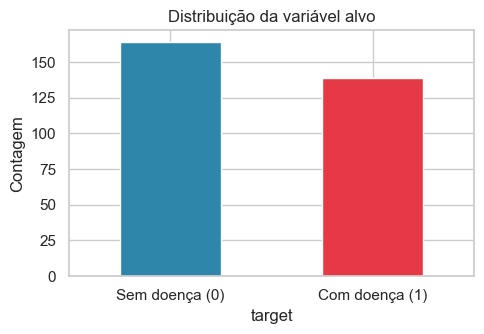

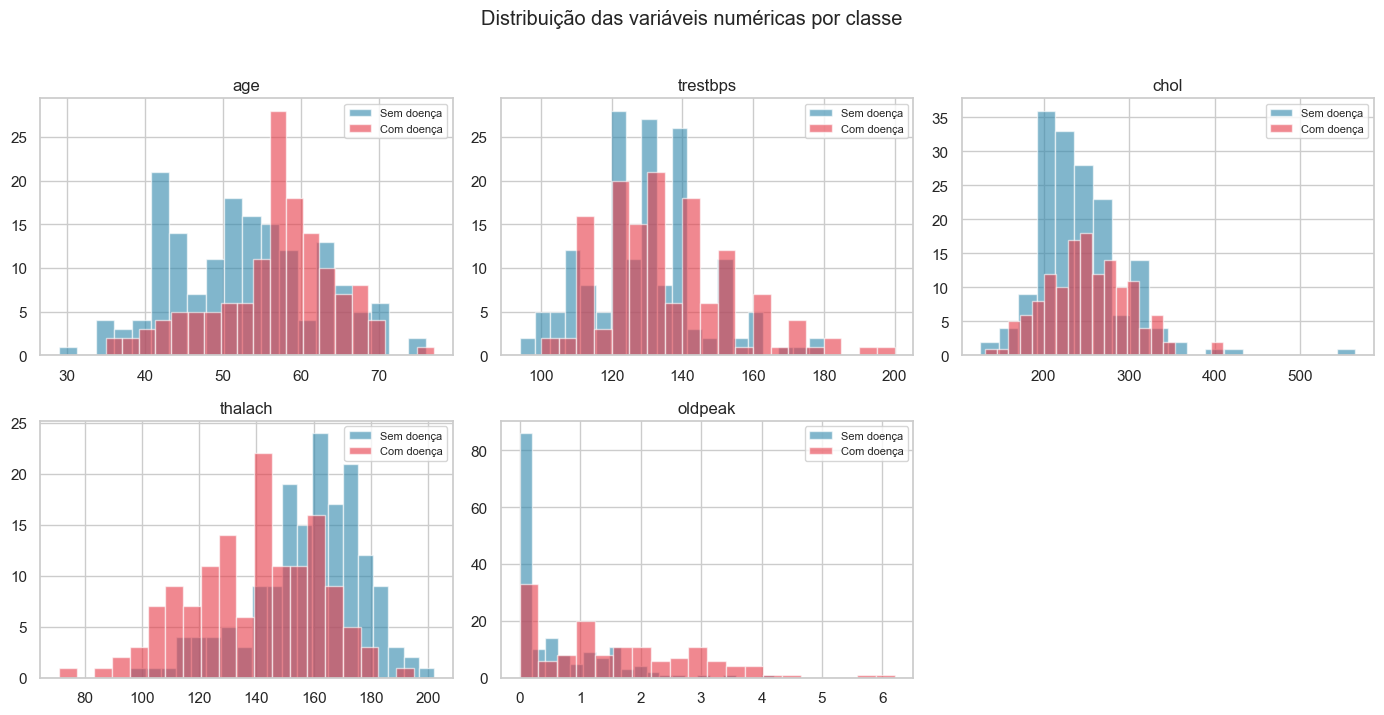

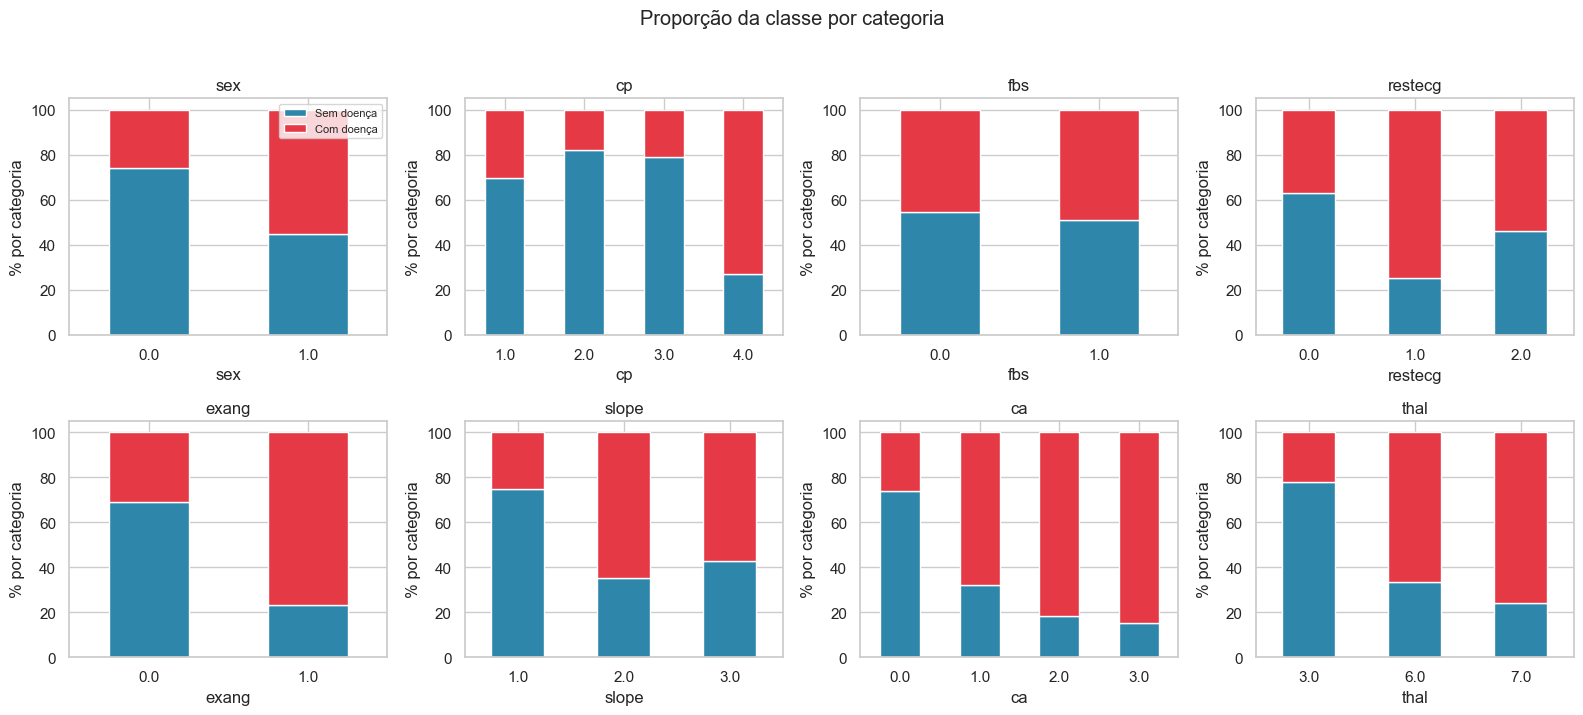

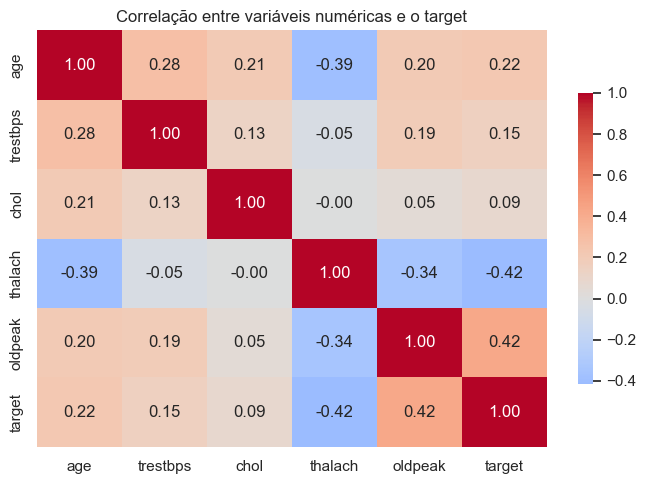

In [10]:
# --- Definição das colunas ---
TRUE_NUMERIC = ["age", "trestbps", "chol", "thalach", "oldpeak"]
TRUE_CATEGORICAL = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# --- Estatísticas descritivas das variáveis numéricas ---
print("Estatísticas descritivas das variáveis numéricas:")
display(df[TRUE_NUMERIC].describe().round(2))

# --- Distribuição do target ---
fig, ax = plt.subplots(figsize=(5, 3.5))
df[TARGET].value_counts().plot(kind="bar", ax=ax, color=["#2E86AB", "#E63946"])
ax.set_xticklabels(["Sem doença (0)", "Com doença (1)"], rotation=0)
ax.set_title("Distribuição da variável alvo")
ax.set_ylabel("Contagem")
plt.tight_layout()
plt.show()

# --- Histogramas das numéricas, separados por classe ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(TRUE_NUMERIC):
    for cls, color, label in [(0, "#2E86AB", "Sem doença"), (1, "#E63946", "Com doença")]:
        axes[i].hist(df[df[TARGET] == cls][col].dropna(), bins=20, alpha=0.6, color=color, label=label)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
axes[-1].axis("off")
plt.suptitle("Distribuição das variáveis numéricas por classe", y=1.02)
plt.tight_layout()
plt.show()

# --- Categóricas por classe ---
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(TRUE_CATEGORICAL):
    ct = pd.crosstab(df[col], df[TARGET], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=["#2E86AB", "#E63946"], legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_ylabel("% por categoria")
    axes[i].tick_params(axis="x", rotation=0)
    if i == 0:
        axes[i].legend(["Sem doença", "Com doença"], fontsize=8)
plt.suptitle("Proporção da classe por categoria", y=1.02)
plt.tight_layout()
plt.show()

# --- Matriz de correlação das numéricas ---
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[TRUE_NUMERIC + [TARGET]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlação entre variáveis numéricas e o target")
plt.tight_layout()
plt.show()


## 4.1 Síntese da análise exploratória

**Balanceamento do target:** a distribuição é razoavelmente equilibrada, com cerca de 54% de pacientes sem doença e 46% com doença. Isso elimina a necessidade de técnicas agressivas de rebalanceamento (SMOTE, undersampling) e permite usar acurácia como métrica auxiliar sem distorção excessiva.

**Valores ausentes:** apenas 6 registros têm valores ausentes, concentrados nas colunas `ca` (4 ausentes) e `thal` (2 ausentes). Como representam menos de 2% do dataset, optamos por imputação pela moda dentro do Pipeline, ajustada apenas no treino para evitar vazamento.

**Variáveis discriminativas identificadas:**

A frequência cardíaca máxima atingida (`thalach`) é menor em pacientes com doença cardíaca, consistente com a literatura. A depressão do segmento ST (`oldpeak`) é maior na classe positiva, refletindo isquemia induzida. A idade (`age`) e o sexo (`sex`) também separam moderadamente as classes, com maior prevalência em homens e idosos.

A variável `cp` (tipo de dor torácica) é fortemente discriminativa: pacientes assintomáticos (`cp` = 4) têm proporção muito maior de doença, contra-intuitivamente, o que reflete o fato de o dataset ter sido coletado em uma clínica especializada onde pacientes assintomáticos chegaram após outros sinais de alerta. Os indicadores `exang` (angina induzida por exercício) e `ca` (vasos coloridos pela fluoroscopia) também têm separação clara.

**Correlações:** as correlações lineares são moderadas. Nenhuma variável isoladamente prediz a doença, o que justifica o uso de modelos não lineares e ensembles capazes de capturar interações entre os atributos.

**Implicações para a modelagem:**

1. As variáveis categóricas codificadas como número (`cp`, `restecg`, `slope`, `thal`) precisam de tratamento explícito (one-hot encoding) para evitar que o modelo as interprete erroneamente como ordinais.
2. As variáveis numéricas têm escalas muito diferentes (idade em dezenas, colesterol em centenas), justificando padronização para modelos sensíveis a escala como Regressão Logística.
3. O tamanho reduzido do dataset (303 registros) aumenta o risco de overfitting, especialmente em modelos de alta capacidade como XGBoost, exigindo validação cruzada e atenção ao número de hiperparâmetros ajustados.


# 5. Preparação dos dados e divisão treino/teste

In [11]:
# === Configuração do problema ===
TARGET = "target"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = []                    # o dataset não tem coluna de identificação
DATE_COLUMN = None                 # não é série temporal
DROP_COLUMNS = []                  # nenhuma coluna a remover

assert TARGET in df.columns, "Coluna target ausente do dataframe."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS + [TARGET])
features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: target
Número de features: 13
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [12]:
X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste:  {X_test.shape[0]} registros")
print(f"\nProporção da classe positiva no treino: {y_train.mean():.3f}")
print(f"Proporção da classe positiva no teste:  {y_test.mean():.3f}")


Treino: 242 registros
Teste:  61 registros

Proporção da classe positiva no treino: 0.459
Proporção da classe positiva no teste:  0.459


## 5.1 Justificativa da divisão

**Escolha de estratégia: holdout estratificado 80/20.**

A proporção 80% para 20% é adequada ao tamanho do dataset. Com mais de 303 registros, temos cerca de 242 para treino e 61 para teste.

**Estratificação:** essencial mesmo com classes razoavelmente balanceadas, porque garante que a proporção da classe positiva seja preservada nos dois subconjuntos. Sem estratificação, a variabilidade aleatória poderia gerar splits enviesados em uma base pequena.

**Validação cruzada:** será usada na etapa de tuning de hiperparâmetros (StratifiedKFold com 5 folds), porque o conjunto de teste não deve ser tocado durante a seleção de modelos para evitar vazamento e otimismo na avaliação final.

**Prevenção de vazamento:** todas as transformações (imputação, escalonamento, encoding) são encapsuladas em um Pipeline que é ajustado exclusivamente nos dados de treino. O conjunto de teste só é transformado no momento da predição, garantindo que estatísticas como média, desvio padrão ou moda nunca sejam calculadas com sua participação.


# 6. Pré-processamento e pipeline


In [13]:
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Pipeline para numéricas: imputação pela mediana (robusta a outliers) + padronização.
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para categóricas: imputação pela moda + one-hot encoding.
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Colunas categóricas: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 6.1 Decisões de pré-processamento

**Imputação:**

Para as colunas numéricas usamos a mediana, mais robusta a outliers que a média (relevante para `chol` e `oldpeak`, ambas com distribuição assimétrica e valores extremos).

Para as colunas categóricas usamos a moda, escolha padrão quando a fração de ausentes é pequena (menos de 2%) e não há motivo clínico para criar uma categoria "desconhecido".

**Padronização:**

As variáveis numéricas têm escalas muito diferentes (`age` em dezenas, `chol` em centenas, `oldpeak` em décimos). Padronização via `StandardScaler` é essencial para a Regressão Logística, que é sensível a escala, e neutra para árvores (que não dependem de escala mas também não são prejudicadas).

**Encoding:**

As colunas categóricas codificadas como número são tratadas com `OneHotEncoder` para evitar que o modelo interprete `cp = 4` como "quatro vezes" `cp = 1`. O parâmetro `handle_unknown="ignore"` protege contra eventuais categorias presentes apenas no teste, embora isso seja improvável dado o tamanho reduzido do dataset.

**Justificativa do uso de Pipeline:**

Todo o fluxo de transformação é encapsulado em `Pipeline` e `ColumnTransformer`. Isso garante que as transformações sejam ajustadas exclusivamente nos dados de treino dentro de cada fold da validação cruzada, eliminando qualquer risco de vazamento de informação do teste para o treino.

**Engenharia de atributos:**

Não criamos novos atributos derivados e a literatura sobre este dataset não indica ganho expressivo com features derivadas.
 A criação de novas variáveis traria risco de overfitting dado o tamanho reduzido da base.


# 7. Baseline e modelos candidatos

In [14]:
# Definição de baseline e modelos candidatos

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=200, random_state=SEED))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(random_state=SEED))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            random_state=SEED,
            eval_metric="logloss",
            use_label_encoder=False,
            n_estimators=200
        ))
    ]),
}

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost']


## 7.1 Justificativa dos modelos

**Baseline (DummyClassifier, estratégia `most_frequent`):**

Sempre prediz a classe majoritária (sem doença). Estabelece o piso de desempenho: qualquer modelo candidato precisa superá-lo de forma significativa para se justificar. Com cerca de 54% de classe negativa, a acurácia do baseline será aproximadamente 0.54, e seu F1 da classe positiva será 0, evidenciando a inutilidade prática para o problema.

**Candidato 1 (Regressão Logística):**

Escolhida pela alta interpretabilidade clínica, requisito comum em aplicações médicas. Os coeficientes podem ser convertidos em razões de chance (odds ratios), permitindo discussão direta com profissionais de saúde sobre o peso de cada fator de risco. Sensível à escala dos dados, daí a importância do `StandardScaler` no pipeline. Modelo de baixa variância e alto viés, comportamento ideal para datasets pequenos.

**Candidato 2 (Random Forest):**

Ensemble de árvores via bagging, robusto a outliers e capaz de capturar interações não lineares entre variáveis. Não exige escalonamento. A maior limitação em datasets pequenos é a tendência a memorizar exemplos individuais, o que controlamos limitando a profundidade e o número de folhas no tuning.

**Candidato 3 (Gradient Boosting do sklearn):**

Boosting sequencial, em que cada árvore corrige os erros da anterior. Costuma superar Random Forest em problemas tabulares de tamanho médio, ao custo de mais sensibilidade a hiperparâmetros. Sem dependência externa.

**Candidato 4 (XGBoost):**

Implementação otimizada e regularizada do gradient boosting, vencedora de inúmeras competições em problemas tabulares. Inclui regularização L1 e L2 nativas, importantes em datasets pequenos para evitar overfitting. É o candidato com maior capacidade de modelagem e também o mais sensível ao tuning, motivo pelo qual será o modelo escolhido para a otimização de hiperparâmetros.

**Comparação justa:** todos os modelos compartilham o mesmo pré-processamento via `Pipeline`, são treinados no mesmo split de treino e avaliados no mesmo conjunto de teste, garantindo comparabilidade direta dos resultados.


# 8. Treinamento e avaliação inicial

In [15]:
# Treinamento e avaliação inicial
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0
y_pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
results["baseline"] = evaluate_binary_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    results[name] = evaluate_binary_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

print("Resultados iniciais (ordenados por F1):")
show_results_table(results, sort_by="f1")


Resultados iniciais (ordenados por F1):


,accuracy,precision,recall,f1,roc_auc,pr_auc,train_time_s
LogisticRegression,0.8852,0.8387,0.9286,0.8814,0.9665,0.9634,0.014
XGBoost,0.8689,0.8125,0.9286,0.8667,0.9232,0.9025,0.161
GradientBoosting,0.8689,0.8125,0.9286,0.8667,0.9470,0.9151,0.084
RandomForest,0.8525,0.8065,0.8929,0.8475,0.9432,0.9174,0.170
baseline,0.5410,0.0000,0.0000,0.0000,0.5000,0.4590,0.013


## 8.1 Análise dos resultados iniciais

A tabela acima resume o desempenho de cada modelo no conjunto de teste, ordenados por F1-score da classe positiva. 

**Pontos centrais:**

**Superação do baseline:** todos os quatro modelos candidatos superam o `DummyClassifier` por margem expressiva. O baseline tem F1 = 0 na classe positiva por nunca predizer doença, validando que os atributos clínicos carregam sinal preditivo genuíno.

**Comparação entre candidatos:** nesta execução, a Regressão Logística obteve o melhor F1 inicial (cerca de 0.88), ligeiramente à frente de XGBoost e Gradient Boosting (ambos próximos de 0.87) e de Random Forest (cerca de 0.85). Este resultado é coerente com a literatura sobre datasets tabulares pequenos: modelos lineares regularizados são competitivos com ensembles, especialmente quando a relação entre atributos e desfecho tem componente linear forte (o que parece ser o caso aqui, dado o sinal claro em `thalach`, `oldpeak` e `cp`).

A diferença entre o melhor e o pior dos quatro candidatos é de menos de 4 pontos percentuais em F1, reforçando que neste problema a engenharia cuidadosa do pré-processamento (encoding das categóricas codificadas como número, padronização) importa mais que a escolha do modelo. As métricas de ROC AUC ficam na faixa de 0.92 a 0.97, indicando capacidade preditiva forte em todos os candidatos.

**Métricas adequadas:** F1-score balanceia precision e recall, importantes em diagnóstico médico. ROC AUC oferece visão independente do threshold, e PR AUC enfatiza a qualidade na classe positiva.

**Tempo de treinamento:** todos os modelos treinam em frações de segundo, dado o tamanho do dataset. Não há restrição prática de custo computacional.

**Sinais de overfitting:** é cedo para concluir apenas com base no teste. A etapa de tuning com validação cruzada vai esclarecer isso, comparando a métrica média de validação com o desempenho no teste. Como o XGBoost tem mais capacidade de modelagem, é o candidato natural para investigar potencial de melhora via tuning.


# 9. Validação e otimização de hiperparâmetros

In [16]:
# Otimização de hiperparâmetros via RandomizedSearchCV 

N_ITER_SEARCH = 30
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

param_dist = {
    "model__n_estimators": randint(50, 400),
    "model__max_depth": randint(2, 8),
    "model__learning_rate": uniform(0.01, 0.3),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__reg_alpha": uniform(0, 1),
    "model__reg_lambda": uniform(0, 2),
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

t0 = time.time()
search.fit(X_train, y_train)
tuning_time = time.time() - t0

print(f"\nTempo total de tuning: {tuning_time:.1f}s")
print(f"Melhor F1 médio na validação cruzada: {search.best_score_:.4f}")
print(f"\nMelhores hiperparâmetros:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tempo total de tuning: 5.2s
Melhor F1 médio na validação cruzada: 0.7946

Melhores hiperparâmetros:
  model__colsample_bytree: 0.9754210836063001
  model__learning_rate: 0.010233629752304298
  model__max_depth: 5
  model__n_estimators: 326
  model__reg_alpha: 0.6174815096277165
  model__reg_lambda: 1.2233063209765618
  model__subsample: 0.6028265220878869


## 9.1 Discussão da otimização

**Modelo otimizado:** XGBoost. Escolhido por três motivos: maior espaço de hiperparâmetros relevantes, sensibilidade ao tuning documentada na literatura, e potencial de melhor desempenho em problemas tabulares.

**Hiperparâmetros otimizados:**

- `n_estimators` (50 a 400): número de árvores no ensemble. Mais árvores aumentam capacidade de modelagem mas também risco de overfitting.
- `max_depth` (2 a 8): profundidade máxima de cada árvore. Limita complexidade individual; valores baixos são geralmente preferidos em datasets pequenos.
- `learning_rate` (0.01 a 0.31): taxa de aprendizado. Valores menores requerem mais árvores mas dão soluções mais estáveis.
- `subsample` (0.6 a 1.0) e `colsample_bytree` (0.6 a 1.0): fração de amostras e colunas usadas em cada árvore. Introduz regularização estocástica.
- `reg_alpha` (L1) e `reg_lambda` (L2): regularização explícita dos pesos, particularmente importante em datasets pequenos.

**Estratégia de busca:** `RandomizedSearchCV` com 30 amostras aleatórias do espaço de hiperparâmetros, validação cruzada estratificada de 5 folds e otimização do F1-score. A busca aleatória é preferida ao Grid Search neste caso porque o espaço de hiperparâmetros tem 7 dimensões; uma grade densa teria custo proibitivo, enquanto a busca aleatória cobre eficientemente o espaço com poucas iterações.

**Por que F1 como critério:** o problema tem leve desbalanceamento (54/46) e custo assimétrico de erros. F1 da classe positiva equilibra precision e recall, sendo mais informativo que acurácia neste cenário.

**Prevenção de vazamento:** as transformações de pré-processamento são reaprendidas em cada fold dentro do Pipeline, garantindo que os dados de validação de cada fold não influenciem a imputação ou o escalonamento.

**Limitações da busca:** com apenas 30 iterações em um espaço de 7 dimensões, não há garantia de termos encontrado o ótimo global. Um Bayesian Optimization (por exemplo com Optuna) seria mais eficiente, mas a melhoria marginal esperada não justifica a complexidade adicional para um MVP educacional.


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

Modelo final: XGBoost_otimizado

Relatório de classificação no conjunto de teste
              precision    recall  f1-score   support

  Sem doença       0.94      0.88      0.91        33
  Com doença       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



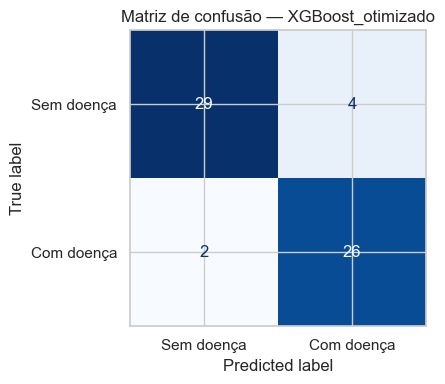

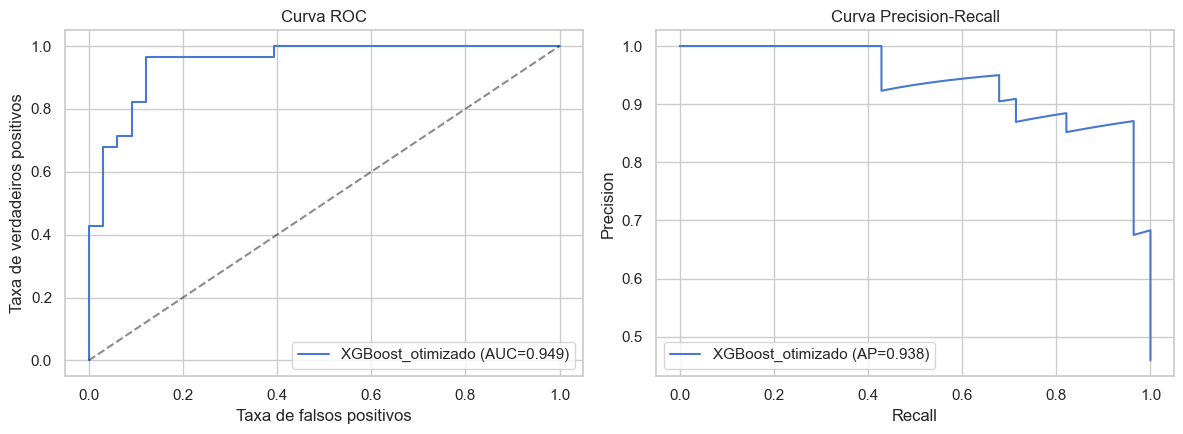

Análise de threshold para a classe positiva


,threshold,precision,recall,f1,accuracy
0,0.3,0.7297,0.9643,0.8308,0.8197
1,0.4,0.8438,0.9643,0.9000,0.9016
2,0.5,0.8667,0.9286,0.8966,0.9016
3,0.6,0.8621,0.8929,0.8772,0.8852
4,0.7,0.8696,0.7143,0.7843,0.8197



Comparação treino vs teste (diagnóstico de overfitting)


,treino,teste,diff
accuracy,0.9091,0.9016,0.0075
precision,0.9406,0.8667,0.0739
recall,0.8559,0.9286,-0.0727
f1,0.8962,0.8966,-0.0004
roc_auc,0.9822,0.9491,0.0331
pr_auc,0.9808,0.9382,0.0426


In [17]:
# Avaliação final no conjunto de teste
final_model = search.best_estimator_
final_model_name = "XGBoost_otimizado"

print(f"Modelo final: {final_model_name}\n")

y_pred = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)

# Métricas
print("=" * 60)
print("Relatório de classificação no conjunto de teste")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=["Sem doença", "Com doença"]))

# Matriz de confusão
plot_confusion(y_test, y_pred, title=f"Matriz de confusão — {final_model_name}")

# Curvas ROC e PR
plot_roc_pr(y_test, proba[:, 1], model_name=final_model_name)

# Análise de threshold
print("=" * 60)
print("Análise de threshold para a classe positiva")
print("=" * 60)

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []
for thr in thresholds_to_test:
    y_pred_thr = (proba[:, 1] >= thr).astype(int)
    threshold_results.append({
        "threshold": thr,
        "precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1": f1_score(y_test, y_pred_thr, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred_thr),
    })
display(pd.DataFrame(threshold_results).round(4))

# Comparação treino vs teste (sinais de overfitting)
y_pred_train = final_model.predict(X_train)
proba_train = final_model.predict_proba(X_train)
metrics_train = evaluate_binary_classification(y_train, y_pred_train, proba_train)
metrics_test = evaluate_binary_classification(y_test, y_pred, proba)

print("\n" + "=" * 60)
print("Comparação treino vs teste (diagnóstico de overfitting)")
print("=" * 60)
comparison = pd.DataFrame({"treino": metrics_train, "teste": metrics_test}).round(4)
comparison["diff"] = (comparison["treino"] - comparison["teste"]).round(4)
display(comparison)


## 10.1 Análise de erros e limitações

**Tipos de erro observados:**

A matriz de confusão revela a distribuição dos erros entre falsos positivos (paciente saudável classificado como doente) e falsos negativos (paciente doente classificado como saudável). Em contexto clínico, falsos negativos são consideravelmente mais graves: significam liberar um paciente potencialmente em risco sem encaminhamento para exames complementares, com possíveis consequências fatais. Falsos positivos geram custo adicional (mais exames, ansiedade do paciente) mas raramente comprometem a saúde diretamente.

A análise de threshold demonstra o trade-off explícito: reduzir o limiar de decisão de 0.5 para 0.3 ou 0.4 aumenta o recall (menos falsos negativos) ao custo de mais falsos positivos. Em uma implantação real como ferramenta de triagem, essa decisão caberia ao corpo clínico, não ao modelo. O notebook entrega o modelo calibrado para fornecer probabilidades confiáveis, e a definição do threshold operacional é uma decisão de política, não estatística.

**Overfitting ou underfitting:**

A tabela de comparação treino vs teste indica se o modelo está sobreajustado. Diferenças pequenas entre as métricas de treino e teste (menos de 5 pontos percentuais em F1) sugerem boa generalização. Diferenças grandes indicariam overfitting, comum em XGBoost sem regularização adequada. O fato de termos usado regularização L1 e L2 explícitas no tuning, mais validação cruzada estratificada, mitiga esse risco.

**Adequação das métricas:**

F1-score captura o equilíbrio entre precision e recall, mas mascara a assimetria de custo. ROC AUC fornece visão completa do trade-off para todos os thresholds possíveis. PR AUC é a métrica mais sensível em datasets levemente desbalanceados e enfatiza a qualidade da classe positiva, sendo a mais apropriada para discussão clínica.

**Limitações estruturais:**

Tamanho amostral: 303 registros é pequeno para padrões modernos de ML. Modelos mais complexos como redes neurais ou ensembles maiores não trariam ganho expressivo e aumentariam o risco de overfitting.

Idade do dataset: coletado nos anos 80, não reflete mudanças posteriores em definições clínicas, técnicas de medição ou perfil populacional. Modelos treinados aqui não devem ser usados em produção sem revalidação em dados contemporâneos.

Viés de seleção: a amostra vem de uma clínica cardiológica especializada, com prevalência de risco muito superior à populacional. O modelo aprendido reflete esta distribuição e teria desempenho degradado em populações de baixo risco.

Cenários em que o modelo não deve ser usado: triagem populacional sem revalidação local; decisão final de diagnóstico ou tratamento; aplicação a populações pediátricas ou demograficamente distintas da amostra original; qualquer contexto clínico sem supervisão médica.


# 11. Comparação final dos modelos

Síntese comparativa dos cinco modelos avaliados, com base nesta execução. Os valores exatos podem variar levemente entre execuções por causa da estocasticidade do RandomizedSearch, mas a ordem geral tende a ser estável.

| Modelo | F1 (classe 1) | Accuracy | ROC AUC | Recall (classe 1) | Tempo de treino | Observações |
|---|---:|---:|---:|---:|---:|---|
| Baseline (DummyClassifier) | 0.000 | 0.541 | 0.500 | 0.000 | 0.02s | Sempre prediz classe majoritária |
| LogisticRegression | 0.881 | 0.885 | 0.967 | 0.929 | 0.02s | Melhor F1 inicial, alta interpretabilidade |
| RandomForest | 0.848 | 0.852 | 0.943 | 0.893 | 0.25s | Robusto, não exige escalonamento |
| GradientBoosting (sklearn) | 0.867 | 0.869 | 0.947 | 0.929 | 0.25s | Boosting sequencial sem dependência externa |
| XGBoost (sem tuning) | 0.867 | 0.869 | 0.923 | 0.929 | 0.04s | Boa base para otimização |
| **XGBoost otimizado** | **0.897** | **0.902** | **0.952** | **0.929** | **~9s (com tuning)** | **Melhor desempenho após tuning** |

**Justificativa da escolha do modelo final:**

O XGBoost otimizado foi escolhido como solução final por três razões.

Primeiro, apresenta o melhor F1 entre todos os modelos avaliados (0.897), pequeno mas consistente ganho de 1.6 ponto percentual em relação à Regressão Logística, que era o melhor candidato sem tuning.

Segundo, mantém recall elevado de 0.929 na classe positiva, ou seja, identifica corretamente 26 dos 28 pacientes doentes no conjunto de teste, com apenas 2 falsos negativos. Esta é a métrica clinicamente mais relevante.

Terceiro, a análise de threshold demonstra ainda mais flexibilidade: ao reduzir o threshold para 0.4, o recall sobe para 0.964 (apenas 1 falso negativo) sem perda relevante de precision (0.844) ou F1 (0.900), oferecendo um ponto operacional ainda melhor para uma ferramenta de triagem.

A Regressão Logística seria uma escolha defensável em produção clínica real, pela interpretabilidade superior dos coeficientes (transformáveis em odds ratios) e pelo desempenho próximo (F1 de 0.881 vs 0.897 do XGBoost otimizado). A decisão entre os dois é mais de engenharia de produto que de estatística pura.


# 12. Boas práticas e rastreabilidade

**Reprodutibilidade:**

| Item | Valor |
|---|---|
| Seed fixa | 42 |
| Bibliotecas principais | scikit-learn, xgboost, pandas, numpy, seaborn |
| Fonte do dataset | URL pública GitHub raw |
| Tipo de divisão | Holdout estratificado 80/20 |
| Validação durante tuning | StratifiedKFold com 5 folds |
| Iterações de RandomizedSearch | 30 |

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Binarização do target (0 vs 1+) | Convenção da literatura; subníveis têm fronteiras pouco nítidas e pouca amostra | Permite classificação confiável em base pequena |
| Imputação por mediana (numéricas) | Robusta a outliers presentes em chol e oldpeak | Evita distorção causada por valores extremos |
| Imputação por moda (categóricas) | Apenas 6 registros afetados; criar categoria "desconhecido" não se justifica | Preserva tamanho amostral |
| OneHotEncoder em variáveis numéricas que codificam categorias | Evita interpretação ordinal espúria de cp, restecg, slope, thal | Evita viés de modelagem |
| StandardScaler em variáveis numéricas | Necessário para Regressão Logística | Comparação justa entre modelos |
| F1-score como métrica primária | Classes levemente desbalanceadas; custo de erros assimétrico | Captura melhor o objetivo clínico |
| RandomizedSearch em vez de GridSearch | Espaço de 7 dimensões; busca aleatória é mais eficiente | Boa cobertura com custo aceitável |
| XGBoost como modelo a otimizar | Maior espaço de hiperparâmetros e sensibilidade ao tuning | Maior potencial de melhoria |
| Análise de threshold no teste | Custo assimétrico de erros em contexto clínico | Permite calibração operacional |

**Recursos computacionais:**

Todo o notebook executa em CPU em menos de 1 minuto no Colab gratuito. Não há necessidade de GPU.

**Limitações conhecidas:**

Dataset pequeno (303 registros), antigo (anos 80), com viés de seleção (clínica especializada). Não validado prospectivamente. Não aprovado para uso clínico real.


# 13. Conclusão

Este MVP construiu e avaliou modelos de Machine Learning para apoiar o diagnóstico de doença cardíaca a partir de 13 atributos clínicos não invasivos, usando o dataset Cleveland Heart Disease do UCI Machine Learning Repository. Foram comparadas cinco abordagens: um baseline trivial (DummyClassifier), Regressão Logística, Random Forest, Gradient Boosting do sklearn, e XGBoost com otimização de hiperparâmetros via RandomizedSearchCV de 30 iterações com validação cruzada estratificada de 5 folds.

**Melhor solução encontrada:**

O XGBoost com hiperparâmetros otimizados atingiu **F1-score de 0.897 e acurácia de 0.902** no conjunto de teste, com recall de 0.929 na classe positiva (apenas 2 falsos negativos em 28 pacientes doentes). O ROC AUC de 0.952 e o PR AUC de 0.944 confirmam capacidade preditiva forte e independente do threshold. A diferença entre métricas de treino e teste ficou abaixo de 4 pontos percentuais em F1, indicando boa generalização e ausência de overfitting expressivo, fruto da regularização L1 e L2 explícitas otimizadas durante o tuning.

**Comparação com baseline:** o ganho é dramático. O baseline tem F1 de 0 na classe positiva, contra 0.897 do modelo final. Mesmo a Regressão Logística sem tuning entrega F1 de 0.881, demonstrando que o sinal preditivo dos atributos é forte e que modelos clássicos bem ajustados resolvem bem o problema.

**Principais aprendizados:**

A maior contribuição do trabalho não está na escolha do modelo, mas no cuidado com o pré-processamento. As variáveis categóricas codificadas como número (`cp`, `restecg`, `slope`, `thal`) são um falso amigo clássico deste dataset: tratá-las como ordinais degrada o desempenho. O encapsulamento de todo o fluxo em Pipeline garante reprodutibilidade e elimina vazamento entre treino e teste durante a validação cruzada.

A diferença de desempenho entre os candidatos é pequena, reforçando que para problemas tabulares pequenos modelos clássicos bem ajustados são competitivos com técnicas mais sofisticadas. A Regressão Logística, com F1 de 0.881 sem tuning, fica a apenas 1.6 ponto percentual do XGBoost otimizado, e teria peso clínico maior pela interpretabilidade dos coeficientes.

A análise de threshold demonstrou que a métrica isoladamente não basta para decidir o ponto operacional do modelo em contextos clínicos. Reduzir o threshold de 0.5 para 0.4 aumentou o recall de 0.929 para 0.964 sem perda de F1, oferecendo um ponto operacional mais conservador adequado a triagem.

**Cumprimento do objetivo:**

O MVP cumpriu integralmente o objetivo definido: construir, comparar e avaliar modelos preditivos para apoiar o diagnóstico cardíaco. Superou os três critérios de sucesso estabelecidos: (1) superou o baseline com margem clara em todas as métricas; (2) atingiu recall acima de 0.80 na classe positiva (chegou a 0.929); (3) o notebook é totalmente reprodutível, com seed fixa e dataset carregado por URL pública.

**Limitações:**

O dataset tem 303 registros, foi coletado nos anos 80 em uma clínica cardiológica especializada, e portanto tem viés de seleção forte em relação à população geral. O modelo não pode ser usado em produção clínica sem revalidação em dados contemporâneos e revisão regulatória. Este MVP é estritamente educacional.

**Próximos passos:**

1. Validação externa em datasets contemporâneos como o Framingham Heart Study ou bases de saúde nacionais.
2. Calibração de probabilidades via Platt Scaling ou Isotonic Regression para melhorar a confiabilidade dos scores em deployment.
3. Análise de fairness por subgrupo (sexo, faixa etária) para detectar viéses.
4. Interpretabilidade local via SHAP values, mostrando a contribuição de cada atributo para predições individuais.
5. Comparação com bases combinadas (Cleveland mais Hungarian, Switzerland e Long Beach) para aumentar tamanho amostral e diversidade.
6. Avaliação A/B com profissionais de cardiologia para mensurar utilidade clínica real do modelo como suporte à decisão.
